In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as ss
from statsmodels.regression.linear_model import OLS
from statsmodels.api import add_constant
from sklearn.decomposition import FastICA

In [2]:
max_mode = 100
fc = np.loadtxt('../../results/func/fc_mean_fsLR_mmp.txt')
glucose_raw = np.loadtxt('../../results/glucose/mean_fsLR_mmp.txt')
glucose_l = ss.zscore(glucose_raw[:180])
glucose_r = ss.zscore(glucose_raw[180:])
glucose = ss.zscore((glucose_raw))

In [3]:
ica = FastICA(n_components=max_mode, random_state=0).fit(fc)
corr = np.zeros(max_mode)
corr_pearson = np.zeros(max_mode)
for j in range(max_mode):
    glm = OLS(glucose, add_constant(ica.components_.T[:,:j+1])).fit()
    corr[j]=glm.rsquared_adj
    corr_pearson[j]=ss.pearsonr(glucose, glm.predict(add_constant(ica.components_.T[:,:j+1])))[0]

np.savetxt('../../results/models/adjR2_fitting_mmp_ica.txt', corr.T)
np.savetxt('../../results/models/pearonr_fitting_mmp_ica.txt', corr_pearson.T)

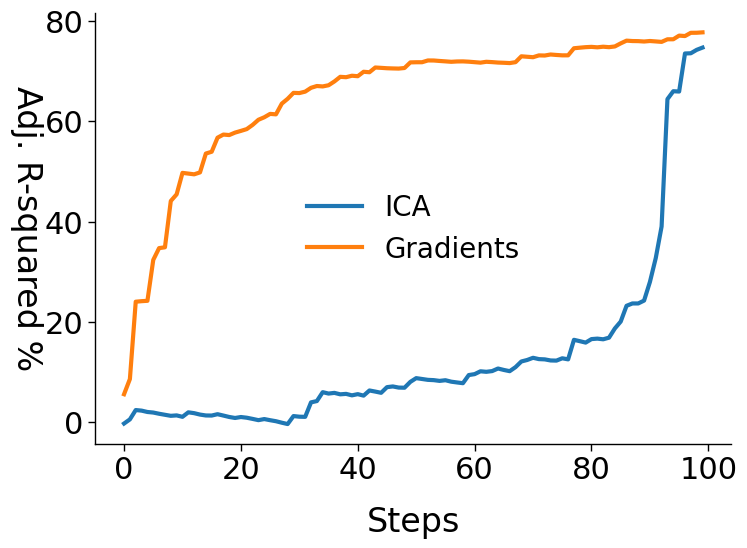

In [4]:
sns.set_context("paper", font_scale = 2.5)
fig, ax = plt.subplots(figsize=(8,6))

ax.plot(range(100), corr*100, lw=3, label='ICA')
ax.plot(range(100), np.loadtxt('../../results/models/adjR2_fitting_mmp.txt')[:,0]*100, lw=3, label='Gradients')
ax.set_xlabel('Steps', labelpad=15)
ax.set_ylabel('Adj. R-squared %', rotation=270, labelpad=25)

ax.set_xticks([0,20,40,60,80,100])
ax.set_yticks([0,20,40,60,80])

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.legend(fontsize=20, frameon=False)

fig.tight_layout()
fig.savefig('../../figures/fitting_fsLR_mmp_ica.png', transparent=True, dpi=300)